<a href="https://colab.research.google.com/github/youssef-Araby/intro-to-ai/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression From Scratch**
In this lab, we will implement linear regression from scratch, train it on a real dataset, visualize the results, and then compare it with scikit-learn's implementation. The goal is to understand how linear regression works both mathematically and practically.

## **Import Liberary**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## **Step 1: Define Functions**
Before training, we define the essential functions:

### **Prediction**
Computes output using the prediction rule
$
y = \theta_0 + \theta_1 x
$

In [ ]:
def predict(X, theta_1, theta_0):
    return theta_1 * X + theta_0

### **Mean Squared Error (MSE)**
Measures average squared difference between actual and predicted values
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

In [ ]:
def mean_squared_error(Y, Y_pred):
    return np.mean((Y - Y_pred)**2)

### **Gradient Descent**
Iteratively updates slope $(\theta_0)$ and intercept $(\theta_1)$ to minimize MSE

Update $\theta_0$:
$$
\theta_0 = \theta_0 - \alpha \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$

Update $\theta_1$:
$$
\theta_1 = \theta_1 - \alpha \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_i
$$

Where:  
- $\theta_0$ = intercept  
- $\theta_1$ = slope  
- $\alpha$ = learning rate  
- $n$ = number of samples  
- $x_i$ = input feature  
- $y_i$ = actual value  
- $\hat{y}_i = \theta_0 + \theta_1 x_i$ = predicted value

In [ ]:
def gradient_descent(X, Y, theta_1, theta_0, learning_rate):
    n = len(X)
    Y_pred = predict(X, theta_1, theta_0)
    D_theta_1 = (1/n) * np.sum((Y_pred - Y) * X)
    D_theta_0 = (1/n) * np.sum(Y_pred - Y)
    theta_1 -= learning_rate * D_theta_1
    theta_0 -= learning_rate * D_theta_0
    return theta_1, theta_0

## **Step 2: Load Dataset**

In [ ]:
df = pd.read_csv('/content/Experience-Salary-Prediction.csv')
print('Dataset loaded successfully! \n')
df.head()

Dataset loaded successfully! 



,Experince,Salary
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


In [ ]:
X = df['Experince'].values
Y = df['Salary'].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('Dataset loaded and split successfully!')

Dataset loaded and split successfully!


## **Step 3: Visualize the Data**

Plot a scatter plot to understand the relationship between hours studied and exam scores.

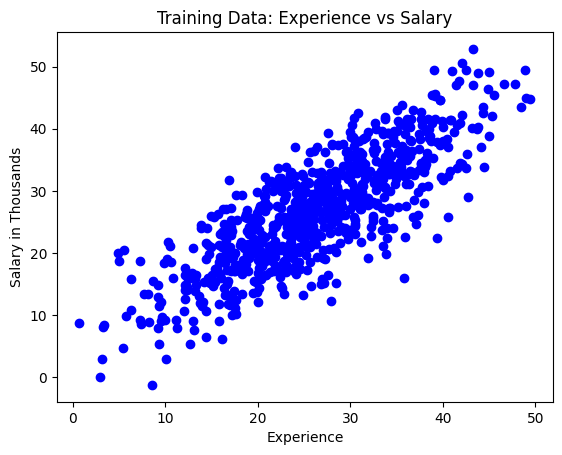

In [ ]:
plt.scatter(X_train, Y_train, color='blue')
plt.xlabel('Experience')
plt.ylabel('Salary in Thousands')
plt.title('Training Data: Experience vs Salary')
plt.show()

## **Step 4: Training the Model**

Here we implement the full training loop in the notebook. We initialize thetas, run gradient descent steps, compute MSE, and print info each iteration.

Epoch 1: MSE=787.5726, theta_1=0.0000, theta_0=0.0000


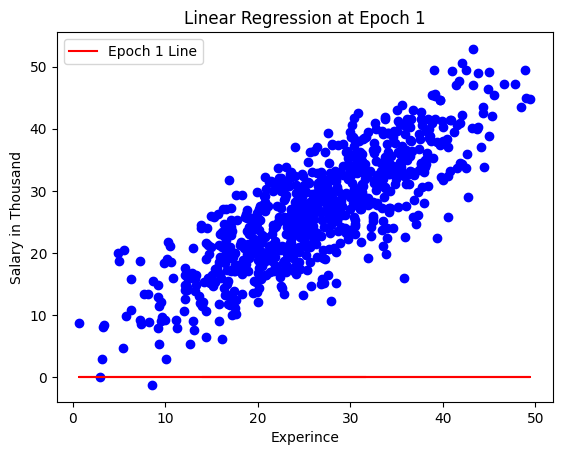

Epoch 100: MSE=28.8929, theta_1=1.0004, theta_0=0.0830


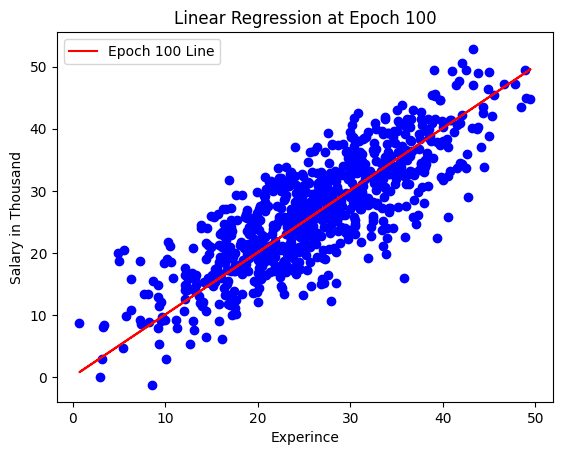

Epoch 200: MSE=28.8459, theta_1=0.9987, theta_0=0.1315


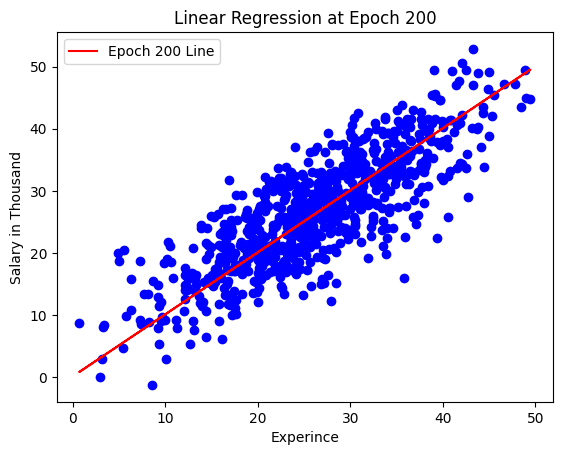

Epoch 300: MSE=28.7999, theta_1=0.9971, theta_0=0.1794


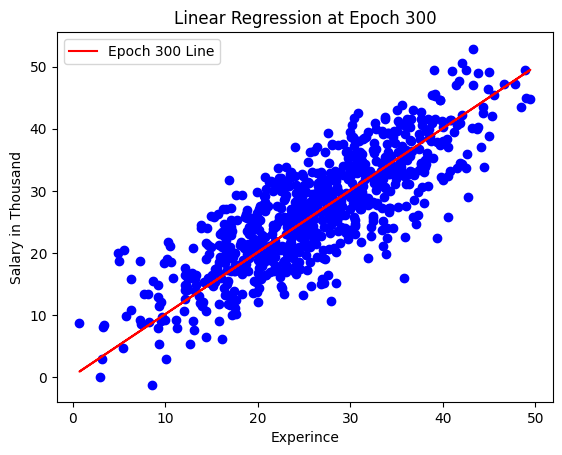

Epoch 400: MSE=28.7548, theta_1=0.9954, theta_0=0.2269


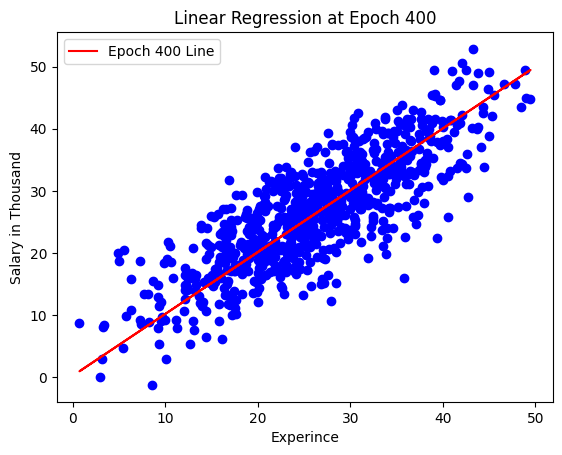

Epoch 500: MSE=28.7106, theta_1=0.9938, theta_0=0.2738


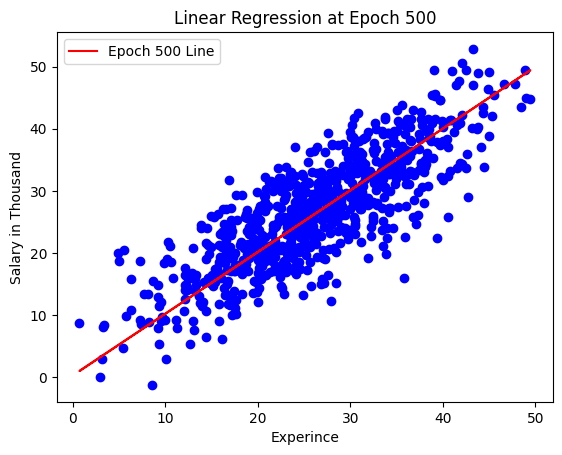

Epoch 600: MSE=28.6673, theta_1=0.9922, theta_0=0.3203


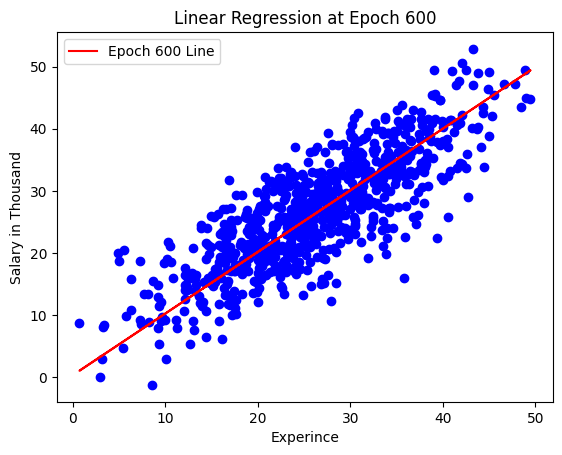

Epoch 700: MSE=28.6248, theta_1=0.9906, theta_0=0.3664


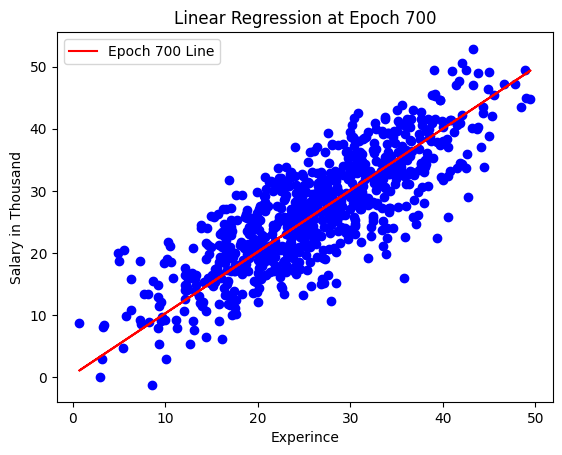

Epoch 800: MSE=28.5832, theta_1=0.9890, theta_0=0.4120


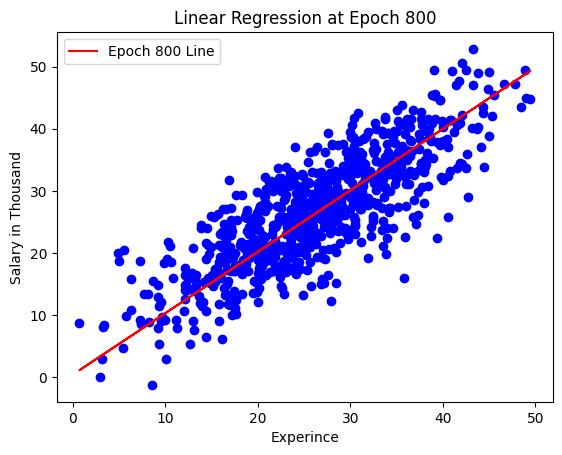

Epoch 900: MSE=28.5425, theta_1=0.9875, theta_0=0.4571


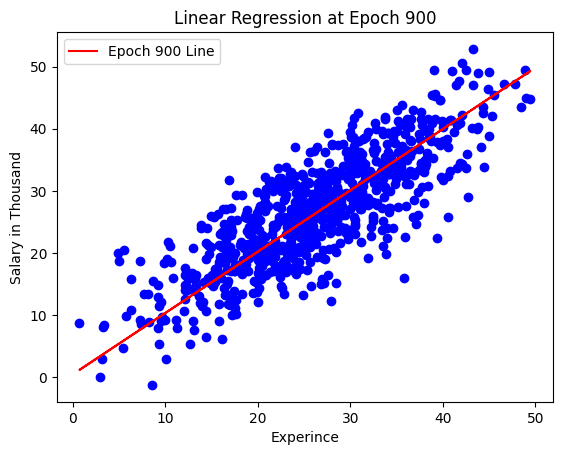

Epoch 1000: MSE=28.5025, theta_1=0.9859, theta_0=0.5018


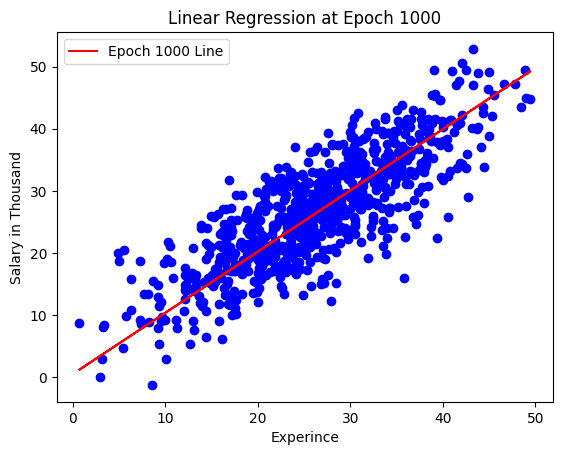

Final model: y = 0.99x + 0.50


In [ ]:
# Initialize parameters
theta_1 = 0
theta_0 = 0
learning_rate = 0.001
epochs = 1000

for epoch in range(1, epochs+1):
    # Make predictions
    Y_pred = predict(X_train, theta_1, theta_0)

    # Compute MSE
    mse = mean_squared_error(Y_train, Y_pred)

    # Print and visualize every 100 iterations
    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch {epoch}: MSE={mse:.4f}, theta_1={theta_1:.4f}, theta_0={theta_0:.4f}')
        plt.scatter(X_train, Y_train, color='blue')
        plt.plot(X_train, predict(X_train, theta_1, theta_0), color='red', label=f'Epoch {epoch} Line')
        plt.xlabel('Experince')
        plt.ylabel('Salary in Thousand')
        plt.title(f'Linear Regression at Epoch {epoch}')
        plt.legend()
        plt.show()

    # Update parameters using the update function
    theta_1, theta_0 = gradient_descent(X_train, Y_train, theta_1, theta_0, learning_rate)

print(f'Final model: y = {theta_1:.2f}x + {theta_0:.2f}')

## **Step 5: Plot the Fitted Line**

Visualize the regression line with the original data points.

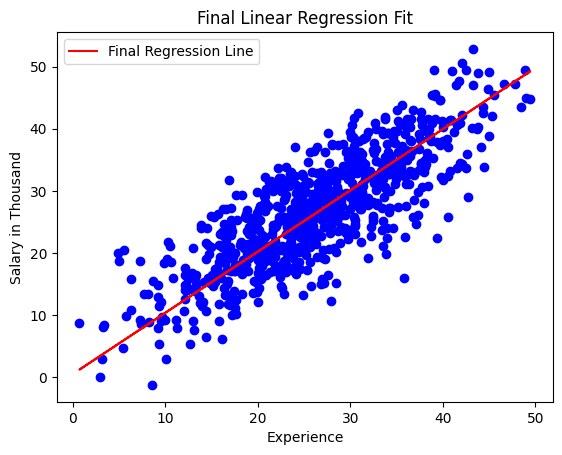

In [ ]:
plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, predict(X_train, theta_1, theta_0), color='red', label='Final Regression Line')
plt.xlabel('Experience')
plt.ylabel('Salary in Thousand')
plt.title('Final Linear Regression Fit')
plt.legend()
plt.show()

## **Step 6: Test the Model**

Predict exam scores for new values of hours studied.

In [ ]:
Y_test_pred = predict(X_test, theta_1, theta_0)
mse = mean_squared_error(Y_test, Y_test_pred)
print(f'Test MSE: {mse:.2f}')

Test MSE: 30.78


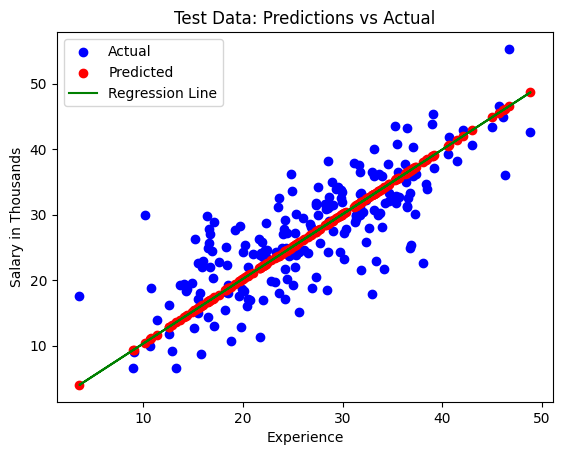

In [ ]:
plt.scatter(X_test, Y_test, color='blue', label='Actual')
plt.scatter(X_test, Y_test_pred, color='red', label='Predicted')
plt.plot(X_test, Y_test_pred, color='green', label='Regression Line')
plt.xlabel('Experience')
plt.ylabel('Salary in Thousands')
plt.title('Test Data: Predictions vs Actual')
plt.legend()
plt.show()

## **Step 7: Linear Regression using scikit-learn**

### Prepare the data shape to fit Linear Regression model in Scikit Learn

In [ ]:
X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

### Train the model

In [ ]:
model = LinearRegression()
model.fit(X_train_reshaped, Y_train)

LinearRegression()

### Test the model

In [ ]:
Y_test_pred_sklearn = model.predict(X_test_reshaped)
mse_test_sklearn = mean_squared_error(Y_test, Y_test_pred_sklearn)
print(f'scikit-learn model: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
print(f'Test MSE (scikit-learn model): {mse_test_sklearn:.4f}')

scikit-learn model: y = 0.83x + 4.91
Test MSE (scikit-learn model): 27.6503


### Visualize the Model

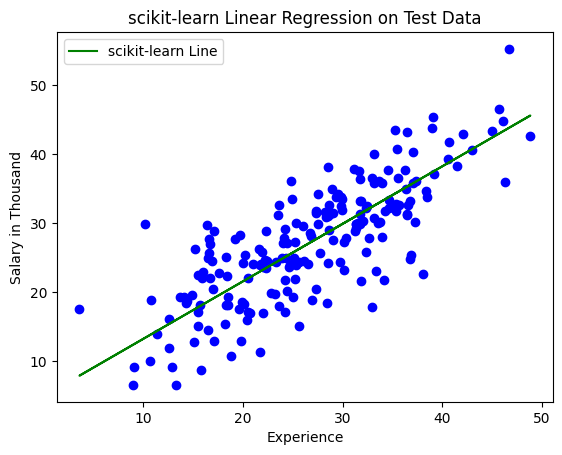

In [ ]:
plt.scatter(X_test, Y_test, color='blue')
plt.plot(X_test, Y_test_pred_sklearn, color='green', label='scikit-learn Line')
plt.xlabel('Experience')
plt.ylabel('Salary in Thousand')
plt.title('scikit-learn Linear Regression on Test Data')
plt.legend()
plt.show()